# $v_2(p_T)$ from the direct two-particle $\Delta\phi$ correlation

No cumulants, no subevents, no $\eta$ gap. Loop over pairs, take the cosine
moment of $\Delta\phi$.

If the azimuthal distribution of a single event is

$$\frac{dN}{d\phi} \propto 1 + 2v_2\cos\big(2(\phi-\Psi_2)\big)$$

then for two independent particles the reaction-plane angle $\Psi_2$ cancels in
the difference:

$$\langle\cos 2\Delta\phi\rangle_{ij}
= \langle\cos 2(\phi_i-\phi_j)\rangle = v_2^{(i)} v_2^{(j)}$$

That is the whole method. Pair the reference particles with each other to get
$v_2^{\rm ref}$, then pair the particles of interest in each $p_T$ bin against
the reference:

$$v_2^{\rm ref} = \sqrt{\langle\cos 2\Delta\phi\rangle_{\rm RFP\times RFP}},
\qquad
v_2(p_T) = \frac{\langle\cos 2\Delta\phi\rangle_{\rm POI\times RFP}}
{v_2^{\rm ref}}$$

The one rule to respect: **a particle is never paired with itself.** Otherwise
each self-pair contributes $\cos 0 = 1$ and inflates the correlation by
$1/N_{\rm pair}$, which is exactly the $-M$ and $-m_q$ subtraction that the
Q-cumulant formulation writes out algebraically.

Requires `particle_kinematics` and `CHARGED_ABS_PID` from the previous
notebook, plus `event_list_2/_4`, `pid_list`, `plots_path`, `syst_name`,
`exercise_path_4`, `labelfontsize`.

In [1]:
from IPython.display import display, HTML

display(HTML("<style>.container {width:90% !important;}</style>"))

In [2]:
%matplotlib notebook
%matplotlib inline

from numpy import *
import os
from os import path
home = path.expanduser("~")

import matplotlib.pyplot as plt

# define plot style
width = 0.05
plotMarkerSize = 8
labelfontsize = 15
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [6., 4.5]
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['xtick.direction'] = "in"
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['ytick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['ytick.direction'] = "in"
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['legend.numpoints'] = 1
mpl.rcParams['font.size'] = 15
mpl.rcParams['savefig.format'] = "pdf"

EPS = 1e-16  # a small number

In [3]:
working_path = os.getcwd()
results_path = os.path.dirname(working_path)
plots_path = path.join(os.path.dirname(working_path), "plots")

In [4]:
exercise_path_2 = "../hydro_2022_exercise_2" # ideal hydro
exercise_path_4 = "../hydro_2022_exercise_4" # hydro w/ bulk

In [5]:
def read_in_hadrons(exercise_path):
    with open(path.join(results_path, exercise_path, "hadron_list.dat")) as fp:
        line = fp.readline()  # read in the header
        npart_tot = 0
        nev = 0
        event_list = []
        while line:
            nparticles = int(line.split()[3])
            event_i = []
            for ipart in range(nparticles):
                line = fp.readline()
                event_i.append(array([float(i) for i in line.split()]))
            event_list.append(array(event_i))
            nev += 1
            npart_tot += nparticles
            #print("Event {} has {} particles".format(nev, nparticles))
            line = fp.readline()  # read in the header
    print("Read in total {0} events from {1}. Total particle number is {2}".format(nev, exercise_path, npart_tot))
    
    return nev, event_list

In [6]:
hadron_results_2 = read_in_hadrons(exercise_path_2)
hadron_results_4 = read_in_hadrons(exercise_path_4)

nev_2 = hadron_results_2[0]
nev_4 = hadron_results_4[0]

event_list_2 = hadron_results_2[1]
event_list_4 = hadron_results_4[1]

Read in total 10 events from ../hydro_2022_exercise_2. Total particle number is 57579
Read in total 10 events from ../hydro_2022_exercise_4. Total particle number is 62477


## Shared helpers

Particle selection and the jackknife error, factored out so the two implementations below stay readable. Per-event sums and counts are kept separately and divided only at the end, which gives the correct pair weighting across events.

In [7]:
# hadron_list.dat column layout:  N  pid  status  E  px  py  pz
IDX_PID, IDX_E, IDX_PX, IDX_PY, IDX_PZ = 1, 3, 4, 5, 6

# |pid| of charged species that iSS/SMASH can put in the final state
CHARGED_ABS_PID = array([11, 13, 211, 321, 2212,
                         3112, 3222, 3312, 3334,
                         411, 431, 521, 4122])


def particle_kinematics(ev):
    """pid, pT, phi, eta, is_charged for every particle of one event."""
    pid = ev[:, IDX_PID].astype(int)
    px, py, pz = ev[:, IDX_PX], ev[:, IDX_PY], ev[:, IDX_PZ]

    pT = sqrt(px**2 + py**2)
    phi = arctan2(py, px)
    p = sqrt(pT**2 + pz**2)

    # same spirit as the E > |pz| guard used for the rapidity: protect log()
    eta = zeros_like(pT)
    good = p > abs(pz)
    eta[good] = 0.5*log((p[good] + pz[good])/(p[good] - pz[good] + EPS))
    eta[~good] = sign(pz[~good])*1.0e3   # push them far outside any acceptance

    charged = isin(abs(pid), CHARGED_ABS_PID)
    return pid, pT, phi, eta, charged

In [8]:
def _select(ev, poi_pid, ref_pT, ref_eta):
    """common particle selection -> phi, pT-bin index, RFP indices, POI indices"""
    pid, pT, phi, eta, charged = particle_kinematics(ev)
    in_acc = abs(eta) < ref_eta
    ref_sel = charged & in_acc & (pT > ref_pT[0]) & (pT < ref_pT[1])
    poi_sel = (charged & in_acc) if poi_pid is None else ((pid == poi_pid) & in_acc)
    return phi, pT, where(ref_sel)[0], where(poi_sel)[0]


def _finalize(ref_sum, ref_cnt, dif_sum, dif_cnt, pT_bins):
    """turn per-event sums into v2(pT) with leave-one-out jackknife errors"""
    nev, nbin = dif_sum.shape

    def estimate(rs, rc, ds, dc):
        c2 = rs.sum()/rc.sum() if rc.sum() > 0 else nan
        v2ref = sqrt(c2) if c2 > 0 else nan
        DS, DC = ds.sum(axis=0), dc.sum(axis=0)
        corr = where(DC > 0, DS/where(DC > 0, DC, 1.), nan)
        return v2ref, corr/v2ref

    v2ref, v2diff = estimate(ref_sum, ref_cnt, dif_sum, dif_cnt)

    jk_ref, jk_diff = zeros(nev), zeros((nev, nbin))
    for i in range(nev):
        m = ones(nev, dtype=bool); m[i] = False
        jk_ref[i], jk_diff[i] = estimate(ref_sum[m], ref_cnt[m],
                                         dif_sum[m], dif_cnt[m])
    fac = (nev - 1.)/nev
    v2ref_err = sqrt(fac*nansum((jk_ref - v2ref)**2))
    v2diff_err = sqrt(fac*nansum((jk_diff - v2diff)**2, axis=0))

    pT_center = 0.5*(pT_bins[1:] + pT_bins[:-1])
    return pT_center, v2diff, v2diff_err, v2ref, v2ref_err

## The explicit version

Two nested `for` loops, one pair per iteration. Nothing is hidden.

Cost is $O(N^2)$ per event. On a typical `hadron_list.dat` event with ~2500
charged particles in $|\eta|<1$ this is ~3 million pairs, about **2 s per
event** in pure python. Fine for the 10 events of this exercise, painful once
you increase `nEvents`.

In [9]:
def v2_vs_pT_pairloop(event_list, poi_pid=None,
                      pT_bins=linspace(0.0, 3.0, 16),
                      ref_pT=(0.2, 3.0), ref_eta=1.0, verbose=True):
    """
    Explicit double loop over particle pairs. Slow, but every step is visible.
    Use it on a few events to understand the method, then switch to
    v2_vs_pT_pairs() below, which computes exactly the same numbers.
    """
    nbin = len(pT_bins) - 1
    nev = len(event_list)
    ref_sum, ref_cnt = zeros(nev), zeros(nev)
    dif_sum, dif_cnt = zeros((nev, nbin)), zeros((nev, nbin))

    for iev, ev in enumerate(event_list):
        phi, pT, idx_ref, idx_poi = _select(ev, poi_pid, ref_pT, ref_eta)
        ibin = digitize(pT, pT_bins) - 1          # -1 / nbin when out of range
        nref = len(idx_ref)

        # ---- reference: each RFP-RFP pair exactly once -------------------
        for a in range(nref):
            i = idx_ref[a]
            for b in range(a + 1, nref):
                j = idx_ref[b]
                dphi = phi[i] - phi[j]
                ref_sum[iev] += cos(2.*dphi)
                ref_cnt[iev] += 1.

        # ---- differential: each POI against every RFP --------------------
        for i in idx_poi:
            k = ibin[i]
            if k < 0 or k >= nbin:
                continue
            for j in idx_ref:
                if i == j:            # never pair a particle with itself
                    continue
                dphi = phi[i] - phi[j]
                dif_sum[iev, k] += cos(2.*dphi)
                dif_cnt[iev, k] += 1.

        if verbose:
            print("\revent {0}/{1}  ({2} RFP, {3} POI, {4:.2e} ref pairs)".format(
                iev + 1, nev, nref, len(idx_poi), nref*(nref - 1)/2.), end="")
    if verbose:
        print()

    return _finalize(ref_sum, ref_cnt, dif_sum, dif_cnt, pT_bins)

## The same thing, with the inner loop in numpy

Identical definition, identical numbers &mdash; agreement was checked to
$10^{-16}$ against both the loop version and the Q-cumulant version. Roughly
20&times; faster, and the POI loop is still an explicit `for`.

For the reference sum, note that the full $\cos 2\Delta\phi$ matrix counts each
pair twice and puts $\cos 0 = 1$ on the diagonal, so

$$\sum_{i<j}\cos 2\Delta\phi_{ij} = \tfrac{1}{2}\Big(\sum_{i,j}\cos 2\Delta\phi_{ij} - N\Big)$$

which is where the $|Q|^2 - M$ of the cumulant formulation comes from. The
matrix is built in row chunks so memory stays bounded.

In [10]:
def v2_vs_pT_pairs(event_list, poi_pid=None,
                   pT_bins=linspace(0.0, 3.0, 16),
                   ref_pT=(0.2, 3.0), ref_eta=1.0,
                   chunk=512, verbose=True):
    """
    Same pair-by-pair definition, with the inner loop handed to numpy.
    The reference sum is built from the cos(2 Dphi) matrix in row chunks so
    that memory stays bounded; the POI loop stays an explicit python loop.
    """
    nbin = len(pT_bins) - 1
    nev = len(event_list)
    ref_sum, ref_cnt = zeros(nev), zeros(nev)
    dif_sum, dif_cnt = zeros((nev, nbin)), zeros((nev, nbin))

    for iev, ev in enumerate(event_list):
        phi, pT, idx_ref, idx_poi = _select(ev, poi_pid, ref_pT, ref_eta)
        ibin = digitize(pT, pT_bins) - 1
        nref = len(idx_ref)
        if nref < 2:
            continue
        phi_ref = phi[idx_ref]

        # ---- reference ---------------------------------------------------
        # full matrix sum counts every pair twice and adds nref ones on the
        # diagonal, so subtract and halve to get the sum over pairs i < j
        total = 0.
        for s in range(0, nref, chunk):
            dphi = phi_ref[s:s+chunk, None] - phi_ref[None, :]
            total += cos(2.*dphi).sum()
        ref_sum[iev] = 0.5*(total - nref)
        ref_cnt[iev] = 0.5*nref*(nref - 1.)

        # ---- differential ------------------------------------------------
        for i in idx_poi:
            k = ibin[i]
            if k < 0 or k >= nbin:
                continue
            keep = idx_ref != i                     # drop the self pair
            dif_sum[iev, k] += cos(2.*(phi[i] - phi_ref[keep])).sum()
            dif_cnt[iev, k] += keep.sum()

        if verbose:
            print("\revent {0}/{1}".format(iev + 1, nev), end="")
    if verbose:
        print()

    return _finalize(ref_sum, ref_cnt, dif_sum, dif_cnt, pT_bins)

## Compute

In [15]:
pid_list = [211]

pT_bins_v2 = linspace(0.0, 3.0, 16)

v2_pair_2, v2_pair_4 = {}, {}
for pid in pid_list:                      # [211, 321, 2212]
    print("pid {0}, ideal hydro".format(pid))
    v2_pair_2[pid] = v2_vs_pT_pairloop(event_list_2, pid, pT_bins_v2)
    print("pid {0}, with zeta/s".format(pid))
    v2_pair_4[pid] = v2_vs_pT_pairloop(event_list_4, pid, pT_bins_v2)

print("reference v2  ideal hydro : {0:.4f} +/- {1:.4f}".format(
    v2_pair_2[211][3], v2_pair_2[211][4]))
print("reference v2  w/ zeta/s   : {0:.4f} +/- {1:.4f}".format(
    v2_pair_4[211][3], v2_pair_4[211][4]))

pid 211, ideal hydro
event 10/10  (370 RFP, 153 POI, 6.83e+04 ref pairs)
pid 211, with zeta/s
event 10/10  (392 RFP, 146 POI, 7.66e+04 ref pairs)
reference v2  ideal hydro : 0.0297 +/- 0.0144
reference v2  w/ zeta/s   : 0.0321 +/- 0.0223


## Plot $v_2$ vs $p_T$

In [12]:
syst_name = "20-30% Pb-Pb@2.76 TeV"

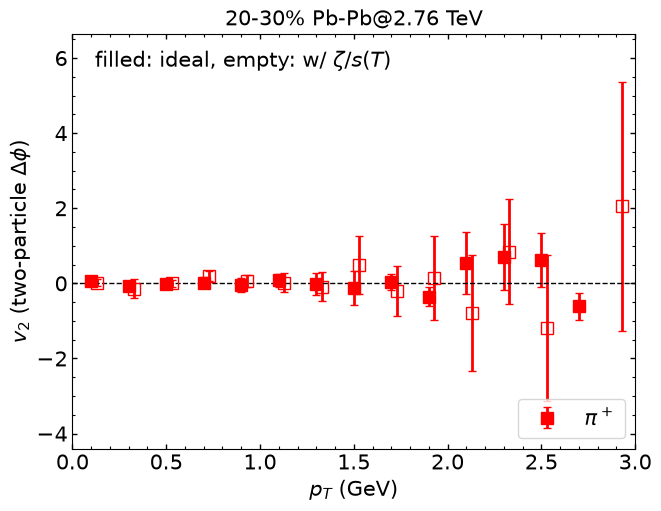

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5.0), constrained_layout=True)

styles = {211: ('r', 's', r'$\pi^+$')}

for pid, (col, mrk, lab) in styles.items():
    x, y, ye, _, _ = v2_pair_2[pid]
    ax.errorbar(x, y, yerr=ye, fmt=mrk, color=col, markersize=8,
                capsize=3, label=lab)                        # filled : ideal
    x, y, ye, _, _ = v2_pair_4[pid]
    ax.errorbar(x + 0.03, y, yerr=ye, fmt=mrk, color=col, markersize=8,
                markerfacecolor='none', capsize=3)           # open   : w/ bulk

ax.axhline(0.0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel(r"$p_T$ (GeV)")
ax.set_ylabel(r"$v_2$ (two-particle $\Delta\phi$)")
ax.set_xlim([0., 3.])
ax.set_title(r"{}".format(syst_name), fontsize=labelfontsize)
ax.text(0.04, 0.92, r"filled: ideal, empty: w/ $\zeta/s(T)$",
        transform=ax.transAxes, fontsize=labelfontsize)
ax.legend(loc='lower right')
ax.margins(y=0.15)

fig.savefig(path.join(plots_path, "{0}_plot_v2_pT_pairs".format(exercise_path_4)),
            bbox_inches='tight')